In [1]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import font_manager
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pandas.api.types import CategoricalDtype
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3

# Figure 5B

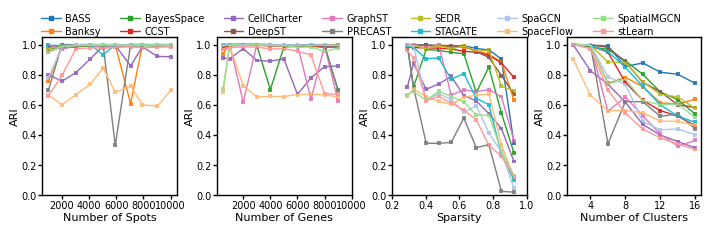

In [2]:
# Figure 5B
df_spot = pd.read_csv("df_spot.csv", index_col = 0)
df_gene = pd.read_csv("df_gene.csv", index_col = 0)
df_sparsity = pd.read_csv("df_sparsity.csv", index_col = 0)
df_cluster = pd.read_csv("df_cluster.csv", index_col = 0)
df_combined = pd.concat([df_spot, df_gene, df_sparsity, df_cluster])
df_meta = pd.read_csv("Data_metadata.csv", index_col = 0)
df_merged = pd.merge(df_combined, df_meta[['Dataset', 'Sample', 'Number of Spots', 'Number of Genes', 'Sparsity', 'Number of Clusters', 'PAS', 'CHAOS', 'ASW']], on=['Dataset', 'Sample'], how='left')

sns.set(style='ticks') 
features = ['Number of Spots', 'Number of Genes', 'Sparsity', 'Number of Clusters']
summary_dict = {}
for feat in features:
    if feat == 'Number of Spots':
        df_feat = df_merged[df_merged['Dataset'] == 'sim2']
    elif feat == 'Number of Genes':
        df_feat = df_merged[df_merged['Dataset'] == 'sim3']
    elif feat == 'Number of Clusters':
        df_feat = df_merged[df_merged['Dataset'] == 'sim4']
    elif feat == 'Sparsity':
        df_feat = df_merged[df_merged['Dataset'] == 'sim6']
    else:
        print('Error')    
    df_summary = df_feat.groupby(['Method', feat], as_index=False).agg(
        mean_ARI=('ARI', 'mean'),
        sd_ARI=('ARI', 'std')
    )
    summary_dict[feat] = df_summary

width_inch = 18 / 2.54
height_inch = 5.5 / 2.54
fig, axes = plt.subplots(1, 4, figsize=(width_inch, height_inch), sharey=False)
method_colors = {
    'BASS': '#1F77B4', 
    'Banksy': '#FF7F0E',
    'BayesSpace': '#2CA02C',
    'CCST': '#D62728',
    'CellCharter': '#9467BD',
    'DeepST': '#8C564B',
    'GraphST': '#E377C2',
    'PRECAST': '#7F7F7F',
    'SEDR': '#BCBD22',
    'STAGATE': '#17BECF',
    'SpaGCN': '#AEC7E8',
    'SpaceFlow': '#FFBB78',
    'SpatialMGCN': '#98DF8A',
    'stLearn': '#FF9896'
}
for i, feat in enumerate(features):
    ax = axes[i]
    df_summary = summary_dict[feat]
    for method, group in df_summary.groupby('Method'):
        ax.plot(group[feat], group['mean_ARI'], label=method, linewidth=1, color=method_colors.get(method, None))
        ax.scatter(group[feat], group['mean_ARI'], color=method_colors.get(method, None), marker='s', s=8, alpha=0.9, edgecolors='none')
    ax.set_ylim(0, 1.05)
    if feat == 'Number of Spots':
        ax.set_xticks([2000, 4000, 6000, 8000, 10000])
    elif feat == 'Number of Genes':
        ax.set_xticks([2000, 4000, 6000, 8000, 10000])
    elif feat == 'Number of Clusters':
        ax.set_xticks([4, 8, 12, 16])
    elif feat == 'Sparsity':
        ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    else:
        print('Error')  
    ax.tick_params(axis='x', labelsize=7, colors='black', pad=1)
    ax.tick_params(axis='y', labelsize=7, colors='black', pad=1)
    ax.tick_params(axis='both', which='major', colors='black', width=1, length=3, pad=1)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
    ax.set_xlabel(feat, fontsize=8, color='black', labelpad=1)
    ax.set_ylabel('ARI', fontsize=8, color='black', labelpad=1)
handles, labels = axes[0].get_legend_handles_labels()
methods = list(method_colors.keys())
handles = [
    Line2D([0], [0], color=method_colors[m],
        marker='s',
        linestyle='-',
        markersize=3,
        linewidth=1,
        label=m) for m in methods]
fig.legend(
    handles, labels,
    loc='upper center',        
    bbox_to_anchor=(0.5, 1.03), 
    ncol=7,                      
    frameon=False,                
    fontsize=7,
    labelcolor='black',
    handletextpad=0.5, labelspacing=0.3, handlelength=2
)
plt.subplots_adjust(left=0.05, right=0.98, top=0.88, bottom=0.15, wspace=0.3, hspace=0.4)
#plt.savefig("Figure5B.pdf")
plt.show()

# Figure 5C

In [ ]:
width_inch = 9 / 2.54
height_inch = 9 / 2.54
fig, axs = plt.subplots(5, 5, figsize=(width_inch, height_inch))
samplelist = ['SRTsim_4_1', 'SRTsim_4_2', 'SRTsim_4_3', 'SRTsim_4_4', 'SRTsim_4_5', 'SRTsim_4_6', 'SRTsim_4_7', 'SRTsim_4_8', 'SRTsim_4_9', 'SRTsim_4_10']
for idx, sample in enumerate(samplelist):
    row, col = divmod(idx, 5)
    ax = axs[row, col]
    h5ad_path = f"Datasets_SRTsim/sim4/{sample}/adata.h5ad"
    adata = sc.read(h5ad_path)
    sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], title=[''], show=False, ax=ax, legend_loc=None, size=1.5)
    ax.set_box_aspect(1)
    ax.set_xlabel('') 
    ax.set_ylabel('') 
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
for ax_row in axs:
    for ax in ax_row:
        if ax and not ax.has_data():
            ax.set_visible(False)
plt.subplots_adjust(left=0.05, right=0.97, top=0.97, bottom=0.04, wspace=0.15, hspace=0.15)
plt.savefig("Figure5C.pdf")
plt.show()

# Figure 5D

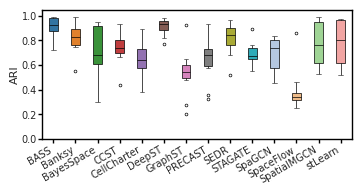

In [3]:
method_colors = {
    'BASS': '#1F77B4', 
    'Banksy': '#FF7F0E',
    'BayesSpace': '#2CA02C',
    'CCST': '#D62728',
    'CellCharter': '#9467BD',
    'DeepST': '#8C564B',
    'GraphST': '#E377C2',
    'PRECAST': '#7F7F7F',
    'SEDR': '#BCBD22',
    'STAGATE': '#17BECF',
    'SpaGCN': '#AEC7E8',
    'SpaceFlow': '#FFBB78',
    'SpatialMGCN': '#98DF8A',
    'stLearn': '#FF9896'
}
width_inch = 9 / 2.54
height_inch = 4.5 / 2.54
fig, ax = plt.subplots(figsize=(width_inch, height_inch))

data = pd.read_csv("df_shape.csv", index_col=0)
data = data.groupby(['Technology', 'Dataset', 'Sample', 'Method']).agg({'ARI': 'mean', 'NMI': 'mean'}).reset_index()

sns.boxplot(
    data=data,
    x='Method',
    y='ARI',
    ax=ax,
    palette=method_colors, 
    hue='Method',
    width=0.4,               
    linewidth=0.5,            
    fliersize=3,               
    showcaps=True,
    boxprops=dict(edgecolor='black'),
    whiskerprops=dict(color='black'),
    medianprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=2, markerfacecolor='none', markeredgecolor='black', markeredgewidth=0.5),
)

ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xlabel('')
ax.set_ylabel('ARI', fontsize=8, labelpad=1)
ax.set_title('')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
ax.tick_params(axis='x', rotation=30, labelsize=7, color='black') 
ax.tick_params(axis='y', labelsize=7, color='black')
ax.tick_params(axis='both', which='major', width=1, length=3, pad=1)
plt.setp(ax.get_xticklabels(), ha='right', rotation=30)
plt.subplots_adjust(left=0.087, right=0.96, top=0.96, bottom=0.23)
#plt.savefig("Figure5D.pdf")
plt.show()

# Figure 5E

In [ ]:
BASE_PATH = f"scCube/sim1"

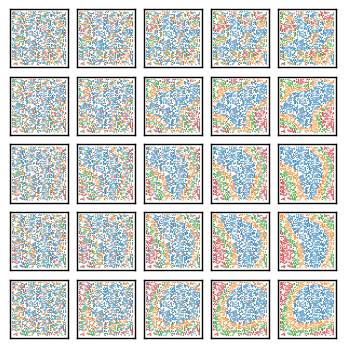

In [10]:
import scanpy as sc
width_inch = 9 / 2.54
height_inch = 9 / 2.54
fig, axs = plt.subplots(5, 5, figsize=(width_inch, height_inch))
#BASE_PATH = f"scCube/sim1"
l1 = ['5', '15', '25', '35', '45']
l2 = ['0.2', '0.4', '0.6', '0.8', '1']
for row in range(5):
    for col in range(5):
        ax = axs[row, col]
        sample = l1[row] + '_' + l2[col]
        h5ad_path = f"{BASE_PATH}/{sample}/adata.h5ad"
        adata = sc.read(h5ad_path)
        sc.pl.embedding(adata, basis='spatial', color=['ground_truth'], title=[''], show=False, ax=ax, legend_loc=None, size=2.5)
        ax.set_box_aspect(1)
        ax.set_xlabel('') 
        ax.set_ylabel('') 
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1)
            spine.set_edgecolor('black')
plt.subplots_adjust(left=0.05, right=0.97, top=0.97, bottom=0.04, wspace=0.15, hspace=0.15)
#plt.savefig("FIgure 5E.pdf")
plt.show()

# Figure 5F

In [16]:
df = pd.read_csv("df_sccube_shape.csv", index_col=0)

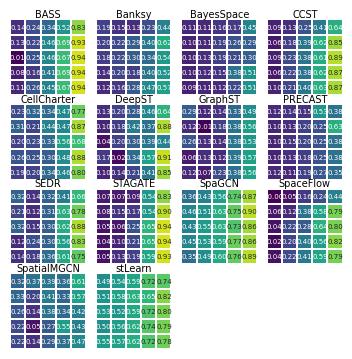

In [17]:
width_inch = 9 / 2.54
height_inch = 9 / 2.54
fig, axs = plt.subplots(4, 4, figsize=(width_inch, height_inch), sharey=False)
Methods = ['BASS', 'Banksy', 'BayesSpace', 'CCST', 'CellCharter', 'DeepST', 'GraphST', 'PRECAST', 'SEDR', 'STAGATE', 'SpaGCN', 'SpaceFlow', 'SpatialMGCN', 'stLearn']
for row in range(4):
    for col in range(4):
        method_index = col + row * 4
        if method_index>13:
            break
        method = Methods[method_index]
        data_subset = df[df['Method'] == method]
        cmap = sns.color_palette("viridis", as_cmap=True)
        sns.heatmap(
            data_subset.pivot(index='delta', columns='lamda', values='ARI'),
            cmap=cmap,
            annot=True,
            fmt=".2f",
            cbar=False,
            linewidths=0.05,
            linecolor='white',
            vmin=0, vmax=1,
            square=True,
            annot_kws={'fontsize': 5},
            ax=axs[row, col]
        )
        axs[row, col].set_box_aspect(1)
        axs[row, col].set_title(method, fontsize=7, pad=0, color='black')
        axs[row, col].set_xlabel('') 
        axs[row, col].set_ylabel('') 
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
for ax_row in axs:
    for ax in ax_row:
        if ax and not ax.has_data():
            ax.set_visible(False)
plt.subplots_adjust(left=0.02, right=0.96, top=0.97, bottom=0.04, wspace=0.12, hspace=0.12)
#plt.savefig("Figure5F.pdf")
plt.show()